In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
import os

In [3]:
load_dotenv()

True

In [4]:
llm=ChatOpenAI(
    model="openai/gpt-oss-20b",   # Must support structured outputs
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [5]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [6]:
def generate_joke(state:JokeState):
    prompt=f'Generate a joke on the topic {state['topic']}'

    response=llm.invoke(prompt).content
    return {'joke':response}

In [7]:
def generate_explanation(state:JokeState):
    prompt=f"Generate a detail explanation about {state['joke']}"

    response=llm.invoke(prompt).content

    return {'explanation':response}

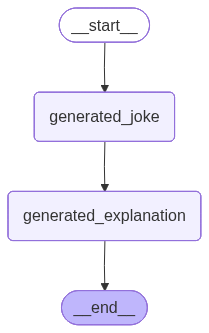

In [8]:
graph=StateGraph(JokeState)
graph.add_node('generated_joke',generate_joke)
graph.add_node('generated_explanation',generate_explanation)

# add edge
graph.add_edge(START,'generated_joke')
graph.add_edge('generated_joke','generated_explanation')
graph.add_edge('generated_explanation',END)

checkpointer=InMemorySaver()
chatbot=graph.compile(checkpointer=checkpointer)
chatbot

In [9]:
config1={'configurable':{'thread_id':1}}
chatbot.invoke({'topic':'pizza'},config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄',
 'explanation': '## Why did the pizza apply for a job?  \n**Because it wanted to get a *crust* of a living!** 🍕😄  \n\nBelow is a deep‑dive into the joke, breaking it down into its linguistic, cultural, and comedic components. Think of it as a “pizza‑ology” lesson—just don’t forget the extra cheese!\n\n---\n\n### 1. The Core of the Joke: Wordplay & Puns\n\n| Element | Explanation |\n|---------|-------------|\n| **Pun** | The punchline hinges on the homophonic similarity between **“crust”** (the outer edge of a pizza) and **“cost”** (the amount of money required to live). |\n| **Play on Phrase** | The phrase **“cost of living”** is a common economic term. Replacing “cost” with “crust” turns a serious concept into a light‑hearted, food‑centric twist. |\n| **Double Meaning** | “Crust” is both a literal part of a pizza and a metaphorical “layer” of life. The joke suggests 

In [10]:
chatbot.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '## Why did the pizza apply for a job?  \n**Because it wanted to get a *crust* of a living!** 🍕😄  \n\nBelow is a deep‑dive into the joke, breaking it down into its linguistic, cultural, and comedic components. Think of it as a “pizza‑ology” lesson—just don’t forget the extra cheese!\n\n---\n\n### 1. The Core of the Joke: Wordplay & Puns\n\n| Element | Explanation |\n|---------|-------------|\n| **Pun** | The punchline hinges on the homophonic similarity between **“crust”** (the outer edge of a pizza) and **“cost”** (the amount of money required to live). |\n| **Play on Phrase** | The phrase **“cost of living”** is a common economic term. Replacing “cost” with “crust” turns a serious concept into a light‑hearted, food‑centric twist. |\n| **Double Meaning** | “Crust” is both a literal part of a pizza and a metaphorical “layer” of life.

In [11]:

list(chatbot.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '## Why did the pizza apply for a job?  \n**Because it wanted to get a *crust* of a living!** 🍕😄  \n\nBelow is a deep‑dive into the joke, breaking it down into its linguistic, cultural, and comedic components. Think of it as a “pizza‑ology” lesson—just don’t forget the extra cheese!\n\n---\n\n### 1. The Core of the Joke: Wordplay & Puns\n\n| Element | Explanation |\n|---------|-------------|\n| **Pun** | The punchline hinges on the homophonic similarity between **“crust”** (the outer edge of a pizza) and **“cost”** (the amount of money required to live). |\n| **Play on Phrase** | The phrase **“cost of living”** is a common economic term. Replacing “cost” with “crust” turns a serious concept into a light‑hearted, food‑centric twist. |\n| **Double Meaning** | “Crust” is both a literal part of a pizza and a metaphorical “layer” of life

In [12]:

config2 = {"configurable": {"thread_id": "2"}}
chatbot.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy?\n\nBecause it couldn’t stop feeling *tortellini*—it was always *twisted* in its own noodles!',
 'explanation': '**Why the Spaghetti Went to Therapy – A Deep‑Dive into Pasta‑Psychology**\n\n---\n\n### 1. The Setup: A Classic Pasta Pun\n\n> *“Because it couldn’t stop feeling *tortellini*—it was always *twisted* in its own noodles!”*\n\nAt first glance, this is a simple, light‑hearted joke that relies on two classic pasta puns:\n\n| Word | Literal Meaning | Punny Twist |\n|------|-----------------|-------------|\n| **Tortellini** | A ring‑shaped stuffed pasta | “Feeling *tortellini*” → *tort‑ell‑ini* → “tort‑ed” (confused, overwhelmed) |\n| **Twisted** | Literally twisted strands | “Twisted in its own noodles” → *twisted* (emotionally tangled) |\n\nBut if we peel back the layers, we can actually craft a surprisingly rich narrative about identity, anxiety, and the universal struggle of being “all over the place.” Let’s break

In [13]:
chatbot.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '## Why did the pizza apply for a job?  \n**Because it wanted to get a *crust* of a living!** 🍕😄  \n\nBelow is a deep‑dive into the joke, breaking it down into its linguistic, cultural, and comedic components. Think of it as a “pizza‑ology” lesson—just don’t forget the extra cheese!\n\n---\n\n### 1. The Core of the Joke: Wordplay & Puns\n\n| Element | Explanation |\n|---------|-------------|\n| **Pun** | The punchline hinges on the homophonic similarity between **“crust”** (the outer edge of a pizza) and **“cost”** (the amount of money required to live). |\n| **Play on Phrase** | The phrase **“cost of living”** is a common economic term. Replacing “cost” with “crust” turns a serious concept into a light‑hearted, food‑centric twist. |\n| **Double Meaning** | “Crust” is both a literal part of a pizza and a metaphorical “layer” of life.

In [14]:

list(chatbot.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '## Why did the pizza apply for a job?  \n**Because it wanted to get a *crust* of a living!** 🍕😄  \n\nBelow is a deep‑dive into the joke, breaking it down into its linguistic, cultural, and comedic components. Think of it as a “pizza‑ology” lesson—just don’t forget the extra cheese!\n\n---\n\n### 1. The Core of the Joke: Wordplay & Puns\n\n| Element | Explanation |\n|---------|-------------|\n| **Pun** | The punchline hinges on the homophonic similarity between **“crust”** (the outer edge of a pizza) and **“cost”** (the amount of money required to live). |\n| **Play on Phrase** | The phrase **“cost of living”** is a common economic term. Replacing “cost” with “crust” turns a serious concept into a light‑hearted, food‑centric twist. |\n| **Double Meaning** | “Crust” is both a literal part of a pizza and a metaphorical “layer” of life

Time Travel

In [15]:
chatbot.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1810a8-8a21-6bbd-8000-567330c2422e"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1810a8-8a21-6bbd-8000-567330c2422e'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [16]:
chatbot.invoke(None,{'configurable':{'thread_id':'1','checkpoint_id':"1f181bda-14c0-6240-8000-ba0a60755811"}})

EmptyInputError: Received no input for __start__

In [ ]:
list(chatbot.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '## Why did the pizza apply for a job?  \n**Because it wanted to get a *crust* of a living!** 🍕😄  \n\nBelow is a deep‑dive into the joke, breaking it down into its linguistic, cultural, and comedic components. Think of it as a “pizza‑ology” lesson—just don’t forget the extra cheese!\n\n---\n\n### 1. The Core of the Joke: Wordplay & Puns\n\n| Element | Explanation |\n|---------|-------------|\n| **Pun** | The punchline hinges on the homophonic similarity between **“crust”** (the outer edge of a pizza) and **“cost”** (the amount of money required to live). |\n| **Play on Phrase** | The phrase **“cost of living”** is a common economic term. Replacing “cost” with “crust” turns a serious concept into a light‑hearted, food‑centric twist. |\n| **Double Meaning** | “Crust” is both a literal part of a pizza and a metaphorical “layer” of life

# Updating State

In [ ]:
chatbot.update_state({'configurable':{'thread_id':'1','checkpoint_id':'1f181bda-14c0-6240-8000-ba0a60755811','checkpoint_ns':""}},{'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f181be6-08d5-6e4c-8001-cd182cd1e295'}}

In [ ]:
list(chatbot.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generated_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f181be6-08d5-6e4c-8001-cd182cd1e295'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-17T09:03:28.884247+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f181bda-14c0-6240-8000-ba0a60755811'}}, tasks=(PregelTask(id='bfe72288-336f-acb1-12a6-ff1d1b2ac8f2', name='generated_joke', path=('__pregel_pull', 'generated_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '## Why did the pizza apply for a job?  \n**Because it wanted to get a *crust* of a living!** 🍕😄  \n\nBelow is a deep‑dive into the joke, breaking it down into its linguistic, cultural, and comedic components. Think of it

In [ ]:
chatbot.invoke(None,{'configurable':{'thread_id':'1','checkpoint_id':'1f181be6-08d5-6e4c-8001-cd182cd1e295'}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it kept feeling *stuffed* inside and wanted to *crack* open a new chapter!',
 'explanation': '**Why the Samosa Went to Therapy: A Deep‑Dive into the Crumb‑by‑Crumb Journey**\n\n---\n\n### 1. The Samosa’s Inner Life: “Stuffed” on the Inside\n\nAt first glance, a samosa is a simple, triangular pastry filled with spiced potatoes, peas, or meat. But if you peel back the layers—both literally and metaphorically—you discover a complex emotional landscape:\n\n| Layer | Physical Description | Emotional Parallel |\n|-------|----------------------|--------------------|\n| **Outer Dough** | Thin, golden, crisp | The “mask” people wear to hide their true feelings |\n| **Inner Filling** | Dense, flavorful, often a mix of textures | The raw, unfiltered emotions that are often hidden |\n| **Crack (the seam)** | The seam where the dough is sealed | The boundary that keeps the inner world from spilling out |\n\nThe samosa’s “stu

In [ ]:
list(chatbot.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it kept feeling *stuffed* inside and wanted to *crack* open a new chapter!', 'explanation': '**Why the Samosa Went to Therapy: A Deep‑Dive into the Crumb‑by‑Crumb Journey**\n\n---\n\n### 1. The Samosa’s Inner Life: “Stuffed” on the Inside\n\nAt first glance, a samosa is a simple, triangular pastry filled with spiced potatoes, peas, or meat. But if you peel back the layers—both literally and metaphorically—you discover a complex emotional landscape:\n\n| Layer | Physical Description | Emotional Parallel |\n|-------|----------------------|--------------------|\n| **Outer Dough** | Thin, golden, crisp | The “mask” people wear to hide their true feelings |\n| **Inner Filling** | Dense, flavorful, often a mix of textures | The raw, unfiltered emotions that are often hidden |\n| **Crack (the seam)** | The seam where the dough is sealed | The boundary that keeps the inner world from spilling out |\

# Fault Tolerance

In [ ]:
from langgraph.graph import StateGraph,END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [ ]:
# define the state
class CrashState(TypedDict):
    input:str
    step1:str
    step2:str

In [ ]:
# Define the steps
def step_1(state:CrashState)->CrashState:
    print("Step 1 excuted")
    return {'step1':'done','input':state['input']}

def step_2(state:CrashState)->CrashState:
    print("Step 2 hanging... now manually interruot from the notebook toolbar {STOP button}")
    time.sleep(1000)
    return {"step2":'done'}

def step_3(state:CrashState)->CrashState:
    print('Step 3 Excuted')
    return {'done':True}


In [ ]:
# Build the graph
builder=StateGraph(CrashState)
builder.add_node('step_1',step_1)
builder.add_node('step_2',step_2)
builder.add_node('step_3',step_3)

builder.set_entry_point('step_1')
builder.add_edge('step_1','step_2')
builder.add_edge('step_2','step_3')
builder.add_edge('step_3',END)

checkpointer=InMemorySaver()
graph=builder.compile(checkpointer=checkpointer)

In [ ]:
try:
    print(" Running graph:Please manually interrupt during step2..")
    graph.invoke({'input':'start'},config={'configurable':{'thread_id':'thread_1'}})
except KeyboardInterrupt:
    print("Kernel mannually interrupted (crash simulated).")

 Running graph:Please manually interrupt during step2..
Step 1 excuted
Step 2 hanging... now manually interruot from the notebook toolbar {STOP button}


In [ ]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...


NameError: name 'graph' is not defined

In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))